In [71]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import re
from scipy import stats
import seaborn as sns
import pingouin as pg
import matplotlib.cm as cm
from matplotlib import rcParams
import matplotlib.ticker as ticker
import statsmodels.stats.power as smp
from statsmodels.stats.anova import AnovaRM

def set_figure_style(scale="1col"):
    """
    Set figure styling based on publication constraints.
    
    Parameters:
        scale (str): Scale of the figure, choose from "1col", "1.5col", "2col".
                     - "1col" for 8.5cm
                     - "1.5col" for 11.6cm
                     - "2col" for 17.6cm
    """
    # Define width options in cm
    widths = {"1col": 7.62, "1.5col": 11.6, "2col": 16.5}
    
    if scale not in widths:
        raise ValueError("Invalid scale. Choose from '1col', '1.5col', or '2col'.")
    
    # Convert width from cm to inches (1 cm = 0.393701 inches)
    width_in = widths[scale] * 0.393701
    
    # Set figure size (width, height)
    # Assuming height proportional to width (Golden Ratio)
    golden_ratio = (5**0.5 - 1) / 2
    rcParams["figure.figsize"] = (width_in, width_in * golden_ratio)
    
    # Set font sizes
    rcParams["font.size"] = 10  # General font size
    rcParams["axes.titlesize"] = 12  # Figure title
    rcParams["axes.labelsize"] = 9  # Axis main label
    rcParams["xtick.labelsize"] = 7  # Tick labels
    rcParams["ytick.labelsize"] = 7
    rcParams["legend.fontsize"] = 8  # Legend entries
    rcParams["figure.titleweight"] = "bold"
    
    # Set stroke width
    rcParams["axes.linewidth"] = 0.75

    
    rcParams["xtick.major.width"] = 0.75
    rcParams["ytick.major.width"] = 0.75

    
    # Subpanel lettering size
    rcParams["text.usetex"] = False  # Set to True if using LaTeX
    rcParams["axes.formatter.use_mathtext"] = True  # Math text for scientific notation

def add_subpanel_label(ax, label, fontsize=20, position=(-0.1, 1.05)):
    """
    Add a subpanel label (e.g., 'a', 'b') to a subplot.
    
    Parameters:
        ax (Axes): Matplotlib Axes object.
        label (str): The label text.
        fontsize (int): Font size for the label.
        position (tuple): Position of the label in axes coordinates.
    """
    ax.text(position[0], position[1], label, transform=ax.transAxes, 
            fontsize=fontsize, fontweight="bold", va="top", ha="left")

###
set_figure_style(scale="1col")

custom_palette = {
    'M': sns.color_palette('colorblind')[0],
    'S': sns.color_palette('colorblind')[7],
    'M+S': sns.color_palette('colorblind')[1],
    'M+S (changed)': sns.color_palette('colorblind')[3]
}




# Experiment 1

In [72]:
# Data structure:
# - SubNum: Subject number 
# - BN: Block number
# - condition: S: random, M+S: repeating, M: repeating masked
# - MT: Movement time in ms
# - ER: Error rate (number of error trials / number of trials)
# - day: Day of the experiment

subjs = pd.read_csv('data/EXP1_subjs_blocks.csv')

num_blocks_per_session = 12
num_trials_per_block = 24
num_trails_per_cond = 8

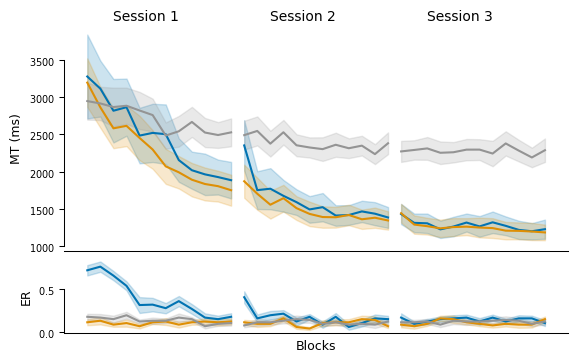

In [73]:
### Plotting MT and ER across blocks ###
set_figure_style(scale = "2col")
gs = plt.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05)

# ---- Movement Time ----
for day, day_data in subjs.groupby('day'):
    sns.lineplot(data = day_data, x = 'BN', y = 'MT', hue = 'condition', errorbar='se',
                palette=custom_palette, ax=plt.subplot(gs[0]), legend=False)

# add text labels for sessions
plt.text(5.5, 4000, 'Session 1', fontsize=10, ha = 'center', va = 'bottom')
plt.text(17.5, 4000, 'Session 2', fontsize=10, ha = 'center', va = 'bottom')
plt.text(29.5, 4000, 'Session 3', fontsize=10, ha = 'center', va = 'bottom')


#removing x axis ticks and labels
plt.gca().xaxis.set_major_locator(ticker.NullLocator())
plt.xlabel('')
plt.ylabel('MT (ms)')


# ---- Error Rate ----
for day, day_data in subjs.groupby('day'):

    sns.lineplot(data = day_data, x = 'BN', y = 'ER', hue ='condition',
                errorbar='se', palette=custom_palette, ax=plt.subplot(gs[1]), legend=False)


#removing x axis ticks and labels
plt.gca().xaxis.set_major_locator(ticker.NullLocator())
plt.xlabel('Blocks')
plt.ylabel('ER')

sns.despine(trim=True)



In [74]:
# Data structure:
# - SubNum: Subject number 
# - condition: S: random, M+S: repeating, M: repeating masked, M+S (changed): violation
# - windowSize: Visible horizon size
# - MT: Movement time in ms
# - ER: Error rate (number of error trials / number of trials)
# - day: Day of the experiment

subjs = pd.read_csv('data/EXP1_subjs.csv')

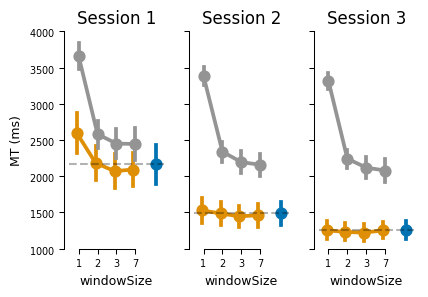

In [78]:
### Plotting MT across window sizes for days 1 to 3 ###
set_figure_style(scale = "1.5col")
fig, axs = plt.subplots(1,3)

day1_to_3 = subjs[subjs['day'] <=3]
for day, session in day1_to_3.groupby('day'):
    fig_idx = day - 1
    sns.pointplot(data = session, x = 'windowSize', y = 'MT', hue = 'condition', errorbar='se',
                dodge = 0.2, palette=custom_palette, ax = axs[fig_idx], legend = False)

    M_data = session[session['condition'] == 'M']

    axs[fig_idx].hlines(M_data['MT'].mean(), -0.5, 4.5, color='black', linestyle='--', alpha = 0.3)
    
    if fig_idx >0:
        # #remove y axis tick labels
        axs[fig_idx].set_ylabel(''), axs[fig_idx].set_yticklabels([])

    if fig_idx == 0:
        axs[fig_idx].set_ylabel('MT (ms)')

    axs[fig_idx].set_xticks([0,1,2,3])    
    axs[fig_idx].set_ylim(1000, 4000)
    axs[fig_idx].set_title(f'Session {day}')

sns.despine(trim=True)
plt.show()

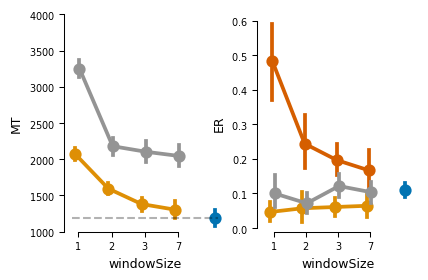

In [82]:
### Plotting MT and ERfor violation condition on day 4 ###
set_figure_style(scale = "1.5col")
fig, axs = plt.subplots(1,2)

violation_day = subjs[subjs['day'] ==4] 
# MT 
sns.pointplot(data = violation_day, x = 'windowSize', y = 'MT', hue = 'condition', errorbar='se',
              dodge = 0.2, palette=custom_palette, legend=False, ax=axs[0])

M_data = violation_day[violation_day['condition'] == 'M']

axs[0].hlines(M_data['MT'].mean(), -0.2, 4.2, color='black', linestyle='--', alpha = 0.3)

axs[0].set_ylim(1000, 4000)
axs[0].set_xticks([0,1,2,3])

# ER
sns.pointplot(data = violation_day, x = 'windowSize', y = 'ER', hue = 'condition',
                dodge = 0.2, palette=custom_palette, legend=False, ax=axs[1])
axs[1].set_xticks([0,1,2,3])

sns.despine(trim=True)

plt.show()

In [83]:
# Data structure:
# - SubNum: Subject number 
# - condition: S: random, M+S: repeating, M: repeating masked, M+S (changed): violation
# - RT: Reaction time in ms
# - ER: Error rate (error presses / total presses)

subjs_presses = pd.read_csv('data/EXP1_violation_subjs_presses.csv')

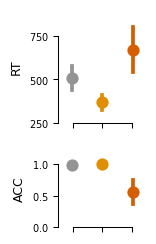

In [84]:
digit_change = [2,3,4]
set_figure_style(scale="1.5col")

fig, (ax0, ax1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3, 2], 'hspace' : 0.3}, sharex=True)
fig.set_size_inches(fig.get_size_inches()[0]/4, fig.get_size_inches()[1] * 1)

# sort RT_data by condition
subjs_presses['condition'] = pd.Categorical(subjs_presses['condition'], categories=['S', 'M+S', 'M+S (changed)'], ordered=True)

# --------- RT at changed pos -------------
sns.pointplot(data = subjs_presses, x = 'condition', y = 'RT', errorbar='sd', dodge = True,
              hue = 'condition', palette=custom_palette, ax=ax0)


# --------- Error rate at changed pos -------------
sns.pointplot(data = subjs_presses, x = 'condition', y = 'ER', errorbar='sd', dodge = True,
                hue = 'condition' ,palette=custom_palette, ax=ax1)


ax0.set_ylabel('RT')
ax1.set_ylabel('ACC')
plt.xlabel('')
plt.xticks(ticks= range(3), labels=['', '', ''], rotation=45)
ax0.set_ylim(250, 900)
ax1.set_ylim([0, 1.2])
ax0.set_yticks([250, 500, 750])
sns.despine(trim=True)

# Experiment 2

In [85]:
# Data structure:
# - SubNum: Subject number 
# - condition: S: random, M+S: repeating, M + S (changed): violation
# - IPI_Value: Inter-press interval in ms
# - dist_to_change: Distance to change position

data = pd.read_csv('data/EXP2_violation_subjs_presses.csv')

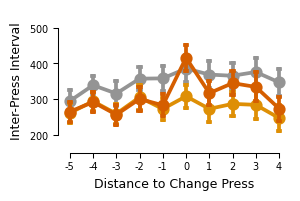

In [86]:
set_figure_style(scale = "1col")
capsize = 5

trained_pallet = sns.light_palette(sns.color_palette('pastel')[1], n_colors=3)

sns.pointplot(data = data, x = 'dist_to_change', y = 'IPI_Value', errorbar = 'se'
              , capsize = 0.1, hue = 'condition', palette=custom_palette, legend=False)

plt.xlabel('Distance to Change Press')
plt.ylabel('Inter-Press Interval')
plt.ylim([150, 550])

sns.despine(trim=True)

plt.show()

# Experiment 3

In [87]:
# Data structure:
# - SubNum: Subject number 
# - condition: S: random, M+S: repeating, M + S (changed): violation
# - IPI_Value: Inter-press interval in ms
# - dist_to_change: Distance to change position
data = pd.read_csv('data/EXP3_violation_subjs_presses.csv')

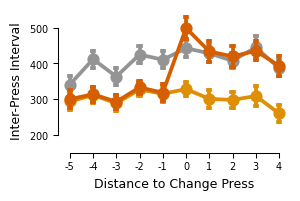

In [88]:
set_figure_style(scale = "1col")
capsize = 5

trained_pallet = sns.light_palette(sns.color_palette('pastel')[1], n_colors=3)

sns.pointplot(data = data, x = 'dist_to_change', y = 'IPI_Value', errorbar = 'se'
              , capsize = 0.1, hue = 'condition', palette=custom_palette, legend=False)

plt.xlabel('Distance to Change Press')
plt.ylabel('Inter-Press Interval')
plt.ylim([150, 550])

sns.despine(trim=True)

plt.show()